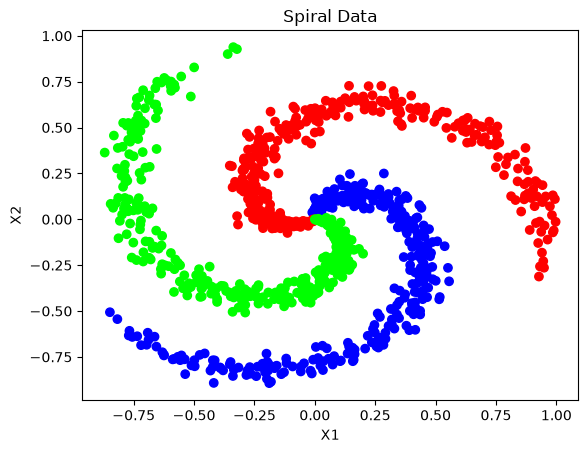

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.layers import Dense  #type:ignore


# Function to generate spiral Data 
def generate_spiral_data(n_points, n_classes):
    X=[]
    Y=[]
    for class_number in range(n_classes):
        ix=range(n_points* class_number, n_points*(class_number+1))
        r=np.linspace(0.0,1,n_points)#radius
        t=np.linspace(class_number*4, (class_number+1)*4, n_points)+np.random.randn(n_points)*0.2 #theta
        X.extend(np.c_[r*np.sin(t), r*np.cos(t)])
        Y.extend([class_number]*n_points)
    return np.array(X), np.array(Y)

#Generate spiral Data 
X,Y=generate_spiral_data(333,3) #999 points, 3 classes

#Plot The Spiral Data
plt.Figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c=Y, cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()



In [4]:
#Split the data into training and test set 
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)

#initialize the scalar
Scaler=StandardScaler()

# Fit the scalar on the Training data
Scaler.fit(X_train)

#Transform the training and testing data 
X_train_scaled=Scaler.transform(X_train)
X_test_scaled=Scaler.transform(X_test)

# Define the model
model= Sequential()
model.add(Dense(64, input_dim=2, activation='relu' ))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))
  

c:\Users\HP\Desktop\python basics\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the Model 
model.compile(optimizer=tf.keras.optimizers.SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
#Fit the model 
history=model.fit(x=X_train_scaled, y=Y_train,
                  validation_data=(X_test_scaled, Y_test),
                  epochs=50, verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.4956 - loss: 0.9757 - val_accuracy: 0.5600 - val_loss: 0.8570
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5620 - loss: 0.8344 - val_accuracy: 0.5800 - val_loss: 0.7422
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5494 - loss: 0.7520 - val_accuracy: 0.5800 - val_loss: 0.6757
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5870 - loss: 0.6975 - val_accuracy: 0.6150 - val_loss: 0.6239
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5932 - loss: 0.6474 - val_accuracy: 0.6700 - val_loss: 0.5740
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6508 - loss: 0.5992 - val_accuracy: 0.7500 - val_loss: 0.5251
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7372 - loss: 0.5482 - val_accuracy: 0.8700 - val_loss: 0.4769
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8298 - loss: 0.4962 - val_accuracy: 0.9100 - v

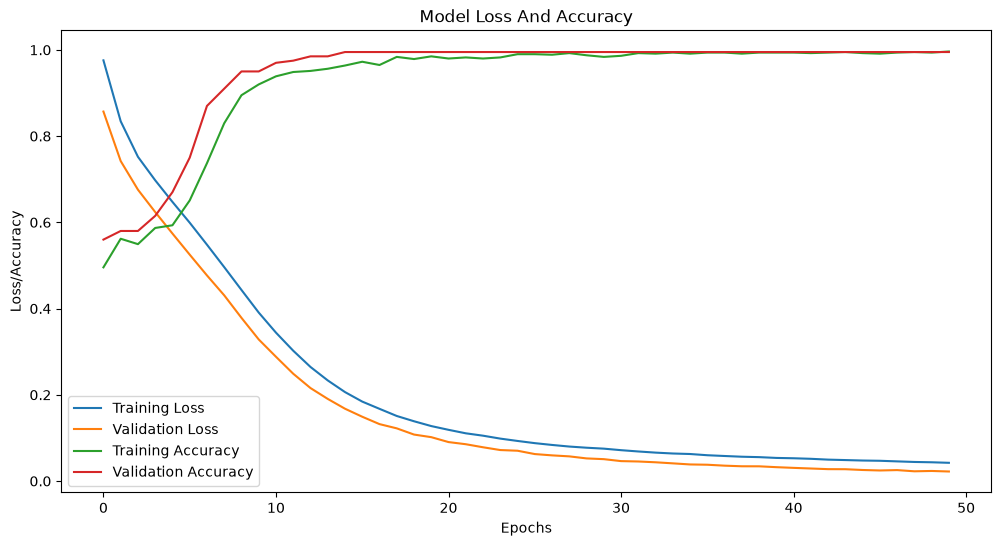

In [9]:
#Plot the Training Data
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Loss And Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


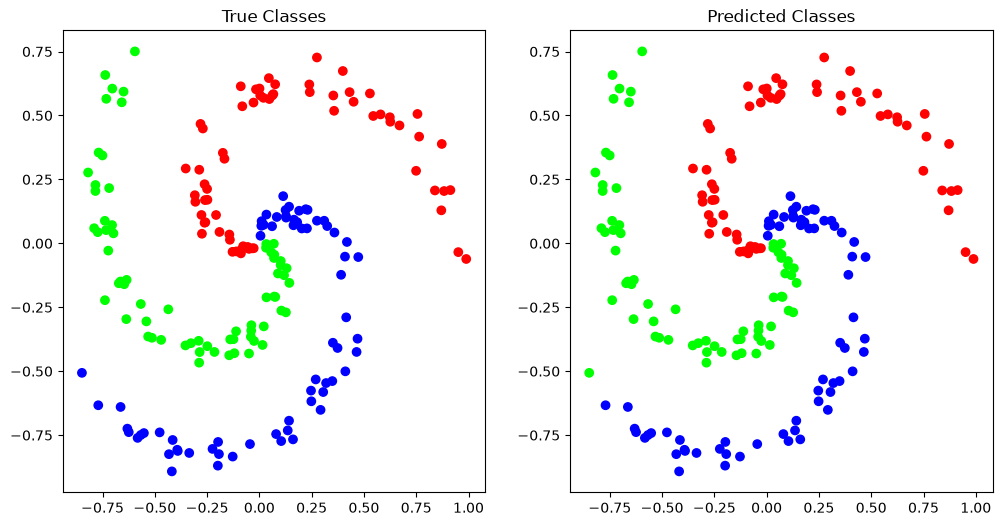

In [11]:
#predict the class for test  data
y_pred=np.argmax(model.predict(X_test_scaled), axis=1)

#plot the comparison of Features
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=Y_test, cmap='brg')
plt.title('True Classes')
plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='brg')
plt.title('Predicted Classes')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


C:\Users\HP\AppData\Local\Temp\ipykernel_5856\3290715065.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


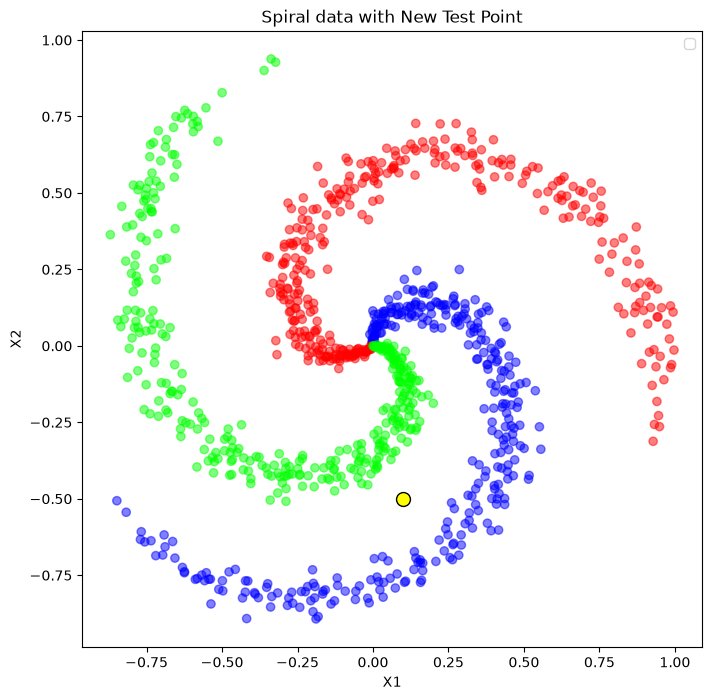

In [12]:
#new test points
new_point=np.array([[0.1,-0.5]])
new_point_scaled=Scaler.transform(new_point)
new_pred=np.argmax(model.predict(new_point_scaled), axis=1)

#color map for legend 
color_map={0:'red', 1:'green', 2:'blue'}

#Plot the new test prediction 
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c=Y, cmap='brg', alpha=0.5)
plt.scatter(new_point[:,0], new_point[:,1], c='yellow',edgecolors='black', s=100)
plt.title('Spiral data with New Test Point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()
